# Common Task 1 — Autoencoder for Quark/Gluon Jet Images

This notebook trains a convolutional autoencoder to learn a compressed representation
of quark and gluon jet images across three detector channels (ECAL, HCAL, Tracks).

**Pipeline:**
1. Load and preprocess jet images
2. Build train/val/test splits
3. Train a convolutional autoencoder
4. Evaluate reconstruction quality
5. Visualize original vs reconstructed events side by side

**Note:** The autoencoder is trained unsupervised — labels are not used during training.
The goal is to learn a compact latent representation of normal jet structure,
which is the foundation for anomaly detection in the GSoC project.

In [2]:
import random
import h5py
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

FILE_PATH = "datasets/quark-gluon_data-set_n139306.hdf5"
BATCH_SIZE = 64
EPOCHS = 15
LR = 1e-4
WEIGHT_DECAY = 1e-4
VAL_SIZE = 0.15
TEST_SIZE = 0.15
PATIENCE = 3

DEVICE = torch.device("cpu")
print("Device:", DEVICE)

Device: cpu


/Users/felipetomepereira/Projects/ml4sci-test/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Loading and Preprocessing

We apply two preprocessing steps before training:

1. **Log transform:** `log1p(x)` compresses the dynamic range of pixel intensities,
   which span several orders of magnitude in calorimeter data. This helps the network
   learn from both low and high energy deposits without being dominated by outliers.

2. **Per-channel normalization:** each channel is normalized by its 99.9th percentile
   (or maximum for very sparse channels like ECAL, where the 99th percentile is zero).
   Values are clipped to [0, 1] with `clamp`. This ensures the three channels contribute
   equally to the reconstruction loss regardless of their absolute energy scales.

In [3]:
with h5py.File(FILE_PATH, "r") as f:
    print("Keys:", list(f.keys()))
    X_raw = f["X_jets"][:]
    y_raw = np.asarray(f["y"][:]).reshape(-1).astype(np.int64)

print("X shape:", X_raw.shape)
print("y shape:", y_raw.shape)
unique, counts = np.unique(y_raw, return_counts=True)
print("Class counts:", dict(zip(unique.tolist(), counts.tolist())))

Keys: ['X_jets', 'm0', 'pt', 'y']
X shape: (139306, 125, 125, 3)
y shape: (139306,)
Class counts: {0: 69653, 1: 69653}


In [6]:
# convert to tensor: HWC -> CHW
X = torch.tensor(X_raw, dtype=torch.float32)

# handle both CHW and HWC input formats
if X.shape[1] <= 6 and X.shape[-1] > 6:
    pass  # already CHW
else:
    X = X.permute(0, 3, 1, 2).contiguous()  # HWC -> CHW

X = torch.log1p(X)

for c in range(X.shape[1]):
    channel_sample = X[:5000, c].numpy().flatten()
    p99 = float(np.percentile(channel_sample, 99.9))
    
    if p99 > 0:
        X_c = (X[:, c] / p99).clamp(0, 1)
    else:
        # canal muito esparso — usa o máximo da amostra
        cmax = float(X[:5000, c].max())
        if cmax > 0:
            X_c = (X[:, c] / cmax).clamp(0, 1)
        else:
            X_c = X[:, c]
    
    X[:, c] = X_c

print(f"Value range: [{X.min():.4f}, {X.max():.4f}]")
for c in range(3):
    print(f"Channel {c} — max: {X[:,c].max():.4f}")

print("X shape after preprocessing:", X.shape)
print(f"Value range: [{X.min():.4f}, {X.max():.4f}]")

Value range: [0.0000, 1.0000]
Channel 0 — max: 1.0000
Channel 1 — max: 1.0000
Channel 2 — max: 1.0000
X shape after preprocessing: torch.Size([139306, 3, 125, 125])
Value range: [0.0000, 1.0000]


## EDA — Quick sanity check before training

We visualize one example per class per channel to confirm preprocessing looks reasonable.
Gluon jets show more spatially spread deposits, while quark jets are more concentrated —
consistent with what the raw data EDA showed in common task 2.

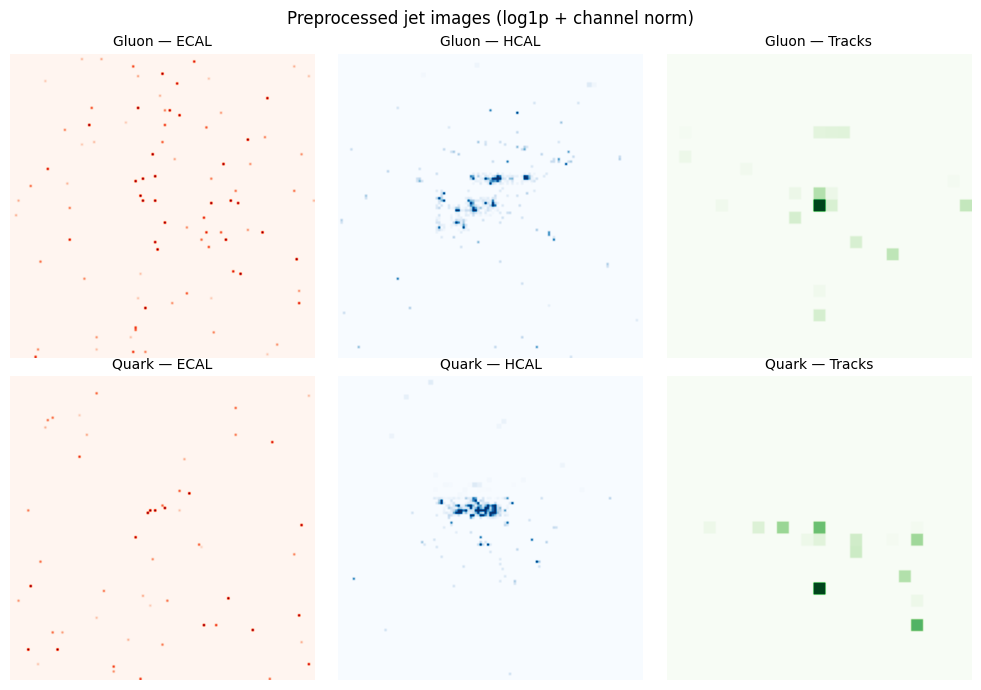

In [7]:
channel_names = ["ECAL", "HCAL", "Tracks"]
channel_cmaps = ["Reds", "Blues", "Greens"]

fig, axes = plt.subplots(2, 3, figsize=(10, 7))

for cls, label in [(0, "Gluon"), (1, "Quark")]:
    idx = np.where(y_raw == cls)[0][0]
    for ch in range(3):
        ax = axes[cls, ch]
        ax.imshow(X[idx, ch].numpy(), cmap=channel_cmaps[ch], origin="lower")
        ax.set_title(f"{label} — {channel_names[ch]}", fontsize=10)
        ax.axis("off")

plt.suptitle("Preprocessed jet images (log1p + channel norm)", fontsize=12)
plt.tight_layout()
plt.show()

## Train / Val / Test Split

Stratified split to preserve class balance across all three sets:
- Train: 70% | Val: 15% | Test: 15%

Labels are kept for visualization and error analysis only —
the autoencoder trains unsupervised on images alone.

In [8]:
y = torch.tensor(y_raw, dtype=torch.long)

indices = np.arange(len(X))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=VAL_SIZE + TEST_SIZE,
    random_state=42,
    stratify=y_raw
)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42,
    stratify=y_raw[temp_idx]
)

X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(TensorDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Train: 97514 | Val: 20896 | Test: 20896


## Model — Convolutional Autoencoder

**Architecture:**
- **Encoder:** 4 convolutional blocks with stride-2 convolutions, progressively
  increasing then compressing channels (3 → 16 → 32 → 64 → 32) and halving
  spatial dimensions at each step
- **Bottleneck:** 32-channel feature map at 8×8 spatial resolution (2,048 values),
  forcing the model to learn a compact representation of the jet structure
- **Decoder:** 4 transposed convolutional blocks mirroring the encoder,
  with Dropout2d(0.1) after the first two blocks to prevent memorization,
  and a final Sigmoid to constrain outputs to [0, 1]

**Loss:** MSE loss — measures pixel-wise reconstruction error.
In the anomaly detection context, anomalous inputs produce higher reconstruction
error than normal inputs, since the model was only trained on the full mixed dataset.

In [9]:
class ConvAutoEncoder(nn.Module):
    def __init__(self, in_channels: int = 3):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, stride=2, padding=1),  # -> 63
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),           # -> 32
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),           # -> 16
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, stride=2, padding=1),           # -> 8  bottleneck menor
            nn.BatchNorm2d(32),
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.1),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.1),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.ConvTranspose2d(16, in_channels, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat[:, :, :125, :125].contiguous()

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x)


model = ConvAutoEncoder(in_channels=3).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Trainable parameters: 84,579


## Training

In [10]:
best_val_loss = float("inf")
patience_counter = 0
best_model_path = "models/best_autoencoder.pt"
history = []

for epoch in range(1, EPOCHS + 1):
    # --- train ---
    model.train()
    train_loss = 0.0
    for X_batch, _ in tqdm(train_loader, desc=f"Epoch {epoch:02d} train", leave=False):
        X_batch = X_batch.to(DEVICE)
        optimizer.zero_grad()
        x_hat = model(X_batch)
        loss = criterion(x_hat, X_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    train_loss /= len(train_loader.dataset)

    # --- validate ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, _ in val_loader:
            X_batch = X_batch.to(DEVICE)
            x_hat = model(X_batch)
            val_loss += criterion(x_hat, X_batch).item() * X_batch.size(0)
    val_loss /= len(val_loader.dataset)

    scheduler.step(val_loss)
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

    print(f"Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

print(f"\nBest val loss: {best_val_loss:.6f}")

Epoch 01/15 | train_loss=0.088530 | val_loss=0.018604


Epoch 02/15 | train_loss=0.009672 | val_loss=0.004799


Epoch 03/15 | train_loss=0.003336 | val_loss=0.002308


Epoch 04/15 | train_loss=0.001951 | val_loss=0.001604


Epoch 05/15 | train_loss=0.001501 | val_loss=0.001340


...

Epoch 11/15 | train_loss=0.000921 | val_loss=0.000823


Epoch 12/15 | train_loss=0.000875 | val_loss=0.000797


Epoch 13/15 | train_loss=0.000853 | val_loss=0.000780


Epoch 14/15 | train_loss=0.000829 | val_loss=0.000712


Epoch 15/15 | train_loss=0.000767 | val_loss=0.000685

Best val loss: 0.000685


## Training Curves

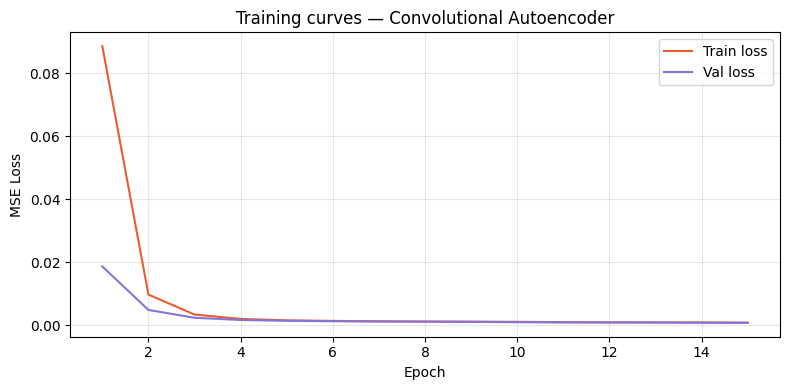

In [11]:
import pandas as pd

hist_df = pd.DataFrame(history)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist_df["epoch"], hist_df["train_loss"], label="Train loss", color="#E85D30")
ax.plot(hist_df["epoch"], hist_df["val_loss"],   label="Val loss",   color="#7F77DD")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Training curves — Convolutional Autoencoder")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Reconstruction Quality — Side-by-side Comparison

We show 3 original and reconstructed events per class (gluon and quark).
Each image is the sum of all 3 channels displayed with the inferno colormap.

The model captures the main energy deposition structure — the central high-energy
core is well preserved. Fine-grained details and isolated low-energy pixels are
smoothed out, which is expected behavior for a compressed bottleneck autoencoder.

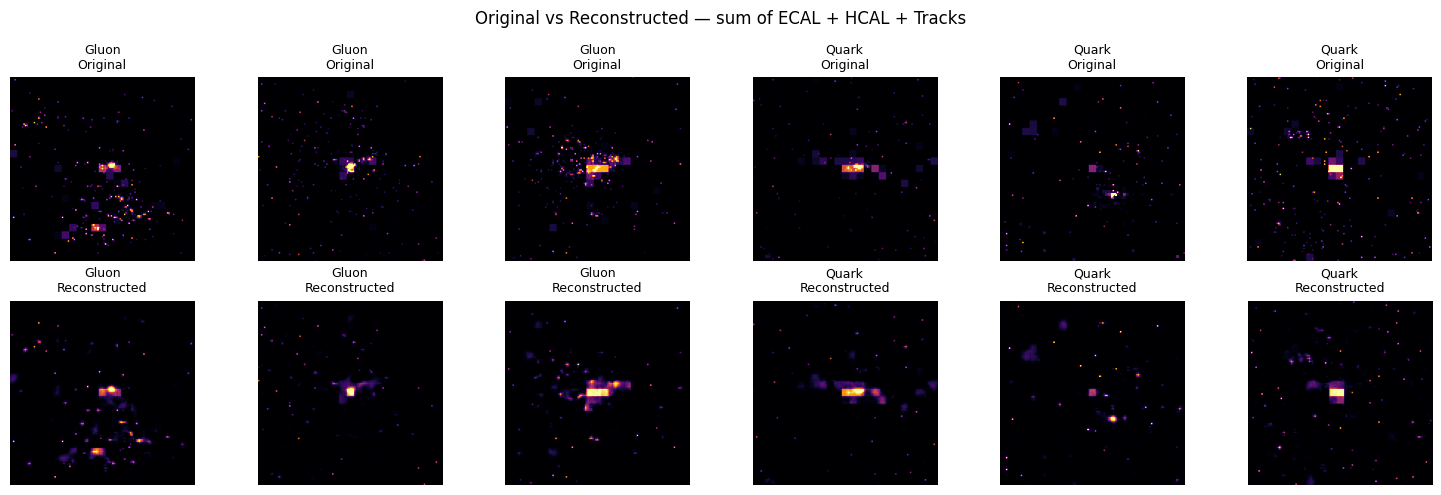

In [13]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()


def plot_jet(ax, image_chw, title):
    img = image_chw.sum(0).detach().cpu().numpy()
    vmax = np.percentile(img, 99.9) if img.max() > 0 else 1.0
    ax.imshow(img, cmap="inferno", vmin=0, vmax=vmax, origin="lower")
    ax.set_title(title, fontsize=9)
    ax.axis("off")


def show_reconstructions(model, loader, n_per_class=3):
    """
    Show n_per_class examples for each class,
    with original and reconstruction side by side.
    """
    quark_imgs, gluon_imgs = [], []
    quark_labels, gluon_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            for img, label in zip(X_batch, y_batch):
                if label.item() == 1 and len(quark_imgs) < n_per_class:
                    quark_imgs.append(img)
                elif label.item() == 0 and len(gluon_imgs) < n_per_class:
                    gluon_imgs.append(img)
            if len(quark_imgs) >= n_per_class and len(gluon_imgs) >= n_per_class:
                break

    all_imgs   = gluon_imgs + quark_imgs
    all_labels = ["Gluon"] * n_per_class + ["Quark"] * n_per_class
    n_total = len(all_imgs)

    batch = torch.stack(all_imgs).to(DEVICE)
    recons = model(batch).cpu()

    fig, axes = plt.subplots(2, n_total, figsize=(n_total * 2.5, 5))

    for i in range(n_total):
        plot_jet(axes[0, i], all_imgs[i],  f"{all_labels[i]}\nOriginal")
        plot_jet(axes[1, i], recons[i],    f"{all_labels[i]}\nReconstructed")

    plt.suptitle("Original vs Reconstructed — sum of ECAL + HCAL + Tracks", fontsize=12)
    plt.tight_layout()
    plt.show()


show_reconstructions(model, val_loader, n_per_class=3)

## Reconstruction Error Distribution

We compute per-event MSE reconstruction error on the test set and plot the
distribution separately for quarks and gluons.

A difference between the two distributions indicates the model reconstructs
one class better than the other — relevant for anomaly detection, where the
reconstruction error is used as an anomaly score.

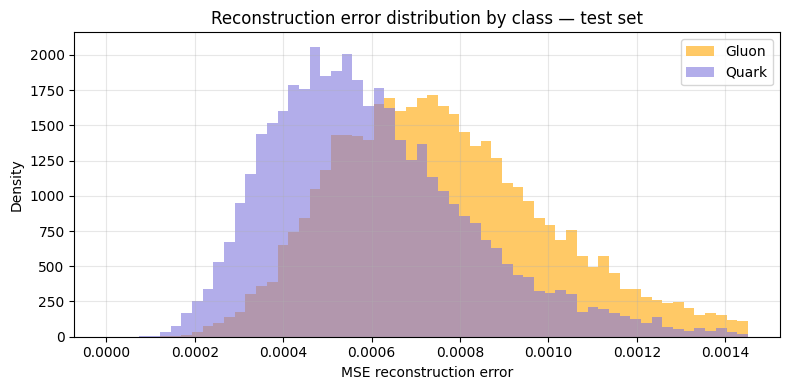

Gluon — mean error: 0.000772
Quark  — mean error: 0.000602


In [14]:
errors = []
labels_all = []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        x_hat = model(X_batch)
        mse = F.mse_loss(x_hat, X_batch, reduction="none")
        mse_per_event = mse.mean(dim=(1, 2, 3)).cpu().numpy()
        errors.extend(mse_per_event)
        labels_all.extend(y_batch.numpy())

errors = np.array(errors)
labels_all = np.array(labels_all)

fig, ax = plt.subplots(figsize=(8, 4))
xmax = np.percentile(errors, 99)
ax.hist(errors[labels_all == 0], bins=60, alpha=0.6, color="orange",
        label="Gluon", density=True, range=(0, xmax))
ax.hist(errors[labels_all == 1], bins=60, alpha=0.6, color="#7F77DD",
        label="Quark",  density=True, range=(0, xmax))
ax.set_xlabel("MSE reconstruction error")
ax.set_ylabel("Density")
ax.set_title("Reconstruction error distribution by class — test set")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Gluon — mean error: {errors[labels_all == 0].mean():.6f}")
print(f"Quark  — mean error: {errors[labels_all == 1].mean():.6f}")

## Discussion

**What the autoencoder learned:**
The model compresses 125×125×3 jet images into a 32×8×8 bottleneck (2,048 values)
and reconstructs them with MSE loss. The reconstruction captures the main energy
deposition structure while smoothing fine-grained details — expected behavior
for a bottleneck autoencoder.

**Reconstruction error by class:**
- Gluon mean error: 0.000772
- Quark mean error: 0.000602

Gluons have higher reconstruction error than quarks. This is consistent with their
broader, more complex spatial structure being harder to compress and reconstruct.
This difference is relevant for the GSoC anomaly detection context: if the model
were trained only on QCD background, new physics events with unusual topology
would be expected to produce even higher reconstruction error.

**Design choices:**
- BatchNorm2d after each conv layer for training stability
- Sigmoid in the decoder to constrain outputs to [0, 1]
- MSE loss — standard for autoencoders and directly interpretable as reconstruction error
- Dropout2d(0.1) in the decoder to prevent memorization
- Smaller bottleneck (32×8×8) to force meaningful compression
- Gradient clipping for training stability

**Connection to the GSoC project:**
This convolutional autoencoder is the reconstruction baseline described in the proposal.
In the anomaly detection framework, reconstruction error serves as the anomaly score —
events deviating from the learned normal distribution produce higher error and are
flagged as anomalous candidates. The graph-based contrastive model proposed for
ML4SCI GENIE extends this idea using learned graph embeddings instead of pixel
reconstruction error.